In [6]:
# Define files and parameters

f_dir = '/data/jupyter/model_distances/'
file_pairs = [
    ('learned_same', 'learned_opp'),
    ('sbert_same', 'sbert_opp')
]

param_dist = ['eu', 'cos']
param_emb = ['64']
param_margin = ['1']



In [ ]:
from scipy.stats import wasserstein_distance
import pandas as pd
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_style('whitegrid')

data = list()
f_dir = '/data/jupyter/model_distances/'

In [62]:


input_file_pair = ('learned_opp_cos_64_05.csv',
                   'learned_same_cos_64_05.csv')


data_learned = list()
for f in input_file_pair:
    file = Path(f_dir).joinpath(f)
    with open(file) as fin:
        values = np.array(list(map(lambda s: s.strip(), fin.readlines())), dtype=float)
    data_learned.extend([(f, v) for v in values])





df_learned = pd.DataFrame(data_learned, columns=['file', 'distance'])


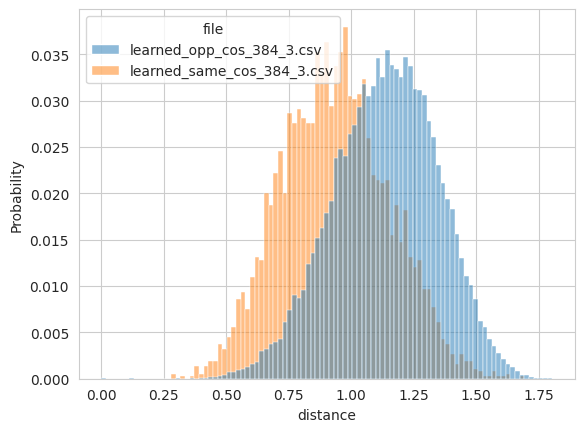

<Figure size 640x480 with 0 Axes>

In [59]:


sns.histplot(data=df_learned, x='distance', 
             hue='file',
             stat='probability',
             common_norm=False)
plt.show();
plt.clf()




In [63]:
# Calculate distribution difference using Wasserstein Distance
# Also called Earth Mover's Distance



# Get the distance values for each group
x_learned_same = df_learned[df_learned['file']==input_file_pair[0]]['distance']
x_learned_opp = df_learned[df_learned['file']==input_file_pair[1]]['distance']
#x_sbert_same = df_sbert[df_sbert['file']==input_file_pair_sbert[0]]['distance']
#x_sbert_opp = df_sbert[df_sbert['file']==input_file_pair_sbert[1]]['distance']


# Compute the Earth mover's distance
d_learned = wasserstein_distance(x_learned_same, x_learned_opp)
#d_sbert = wasserstein_distance(x_sbert_same, x_sbert_opp)
print(f"Earth mover's distance:")
#print(f"   d_learned={d_learned:.4f}  || d_sbert={d_sbert:.4f}")
print(f"   d_learned={d_learned:.4f} ")

Earth mover's distance:
   d_learned=0.1989 
